# EEPAS Italy Preprocessing: Estimation of Completeness ($m_c$) and $b$-value

## 📚 Background

This notebook outlines the procedure for estimating key seismological parameters required to calibrate the **EEPAS (Every Earthquake a Precursor According to Scale)** model. Accurate estimation of these parameters is critical for minimizing bias in the forecasting model.

### 1. Magnitude of Completeness ($m_c$ or $m_0$)
> **Definition:** The minimum magnitude threshold above which the earthquake catalog is considered 100% complete.

* **Role in EEPAS:** This determines the $m_0$ parameter. Events below this threshold are excluded from the learning process to prevent data quality artifacts from skewing the forecast.

### 2. The Gutenberg-Richter $b$-value

> **Definition:** The slope parameter in the empirical frequency-magnitude relationship:
> $$\log_{10} N = a - bM$$
> Where $N$ is the cumulative number of events with magnitude $\ge M$.

* **Physical Interpretation:**
    * **$b \approx 1.0$:** Standard tectonic environment.
    * **$b > 1.0$:** High heterogeneity or low stress (e.g., volcanic regions, swarms).
    * **$b < 1.0$:** High stress accumulation or asperities.
* **Role in EEPAS:** The model utilizes a transformed parameter, $B$, calculated as: $B = b \cdot \ln(10)$

---

## 🎯 Notebook Objectives

1.  **Software Integration:** Demonstrate the integration of external libraries, specifically [SeismoStats](https://seismostats.readthedocs.io/v1.0.0/), for robust statistical analysis.
2.  **Completeness Analysis:** Evaluate $m_c$ using multiple statistical approaches to ensure stability:
    * Maximum Curvature (MaxC)
    * $b$-value Stability
    * Kolmogorov-Smirnov (KS) Test
3.  **$b$-value Estimation:** Compare estimators to handle potential magnitude uncertainties:
    * Utsu method (Maximum Likelihood)
    * $b$-positive
    * $b$-more-positive
4.  **Parameter Selection:** Define the final $m_0$ and $B$ values to be injected into the EEPAS configuration.

---

## 📊 Dataset Profile

| Property | Details |
| :--- | :--- |
| **Catalog Source** | `HORUS_Italy_polygon_filtered.mat` |
| **Spatial Filter** | Italian CPTI15 polygon region |
| **Time Range** | 1960 – 2011 (Includes training and warm-up periods) |
| **Depth Cutoff** | $\le 40$ km |
| **Event Count** | ~174,701 earthquakes |



### Install related packages

In [ ]:
!pip install pycsep -qq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 26.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 130.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython-sql 0.5.0 requires sqlalchemy>=2.0, but you have sqlalchemy 1.4.54 which is incompatible.
google-adk 1.19.0 requires sqlalchemy<3.0.0,>=2.0, but you have sqlalchemy 1.4.54 which is incompatible.


In [ ]:
!pip install git+https://github.com/swiss-seismological-service/SeismoStats.git -qq

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 MB 83.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/HORUS_Italy_polygon_filtered.mat .
!cp /content/drive/MyDrive/00_Image\ meeting/Researches/01_Scratchpad/earthquake/HORUS_Italy_RDN2008_polygon_filtered.mat .
!cp /content/drive/MyDrive/earth_src/src/EEPAS_Taiwan-main/src/analysis/dataset.py /content/

In [ ]:
import csep
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import scipy.io

from csep.utils import time_utils
from seismostats.catalogs.client import FDSNWSEventClient
from seismostats import Catalog
from seismostats.utils.binning import bin_to_precision
from seismostats.analysis.bvalue import UtsuBValueEstimator, BPositiveBValueEstimator, BMorePositiveBValueEstimator

from dataset import extract_period_forecast, generate_all_periods_forecast, create_csep_forecast_file, calculate_date_range, get_top_earthquakes, my_custom_loader_function

Transform the dataset for compatibility with [SeismoStats](https://seismostats.readthedocs.io/v1.0.0rc2/user/10minute_intro.html)

In [ ]:
MAT_FILE_PATH = "/content/HORUS_Italy_polygon_filtered.mat"
mat_data = scipy.io.loadmat(MAT_FILE_PATH)
df_raw = pd.DataFrame(mat_data["HORUS"][:, :10],
                      columns=['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second',
                               'Latitude', 'Longitude', 'Depth', 'Magnitude'])

# --- Process and Filter ---
MAX_YEAR = 2011  # Based on your original code (<= 2011)
MAX_DEPTH = 40
date_cols = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']

# Chain all operations:
# 1. Build the new DataFrame with correct column names and 'time'
# 2. Drop rows where date conversion failed
# 3. Filter by year and depth using .query()
# 4. Sort by time and reset the index
df_processed = (
    pd.DataFrame({
        'time': pd.to_datetime(df_raw[date_cols].astype(int), errors='coerce'),
        'longitude': df_raw['Longitude'],
        'latitude': df_raw['Latitude'],
        'depth': df_raw['Depth'],
        'magnitude': df_raw['Magnitude']
    })
    .dropna(subset=['time'])  # Drop rows with invalid dates
    .query(f"time.dt.year <= {MAX_YEAR} & depth <= {MAX_DEPTH}")
    .sort_values('time')
    .reset_index(drop=True)
)

# --- Create Catalog ---
catalog = Catalog(df_processed)

print(f"✓ Catalog: {len(catalog)} earthquakes (Years <= {MAX_YEAR}, Depth <= {MAX_DEPTH}km)")
print(f"  Time range: {catalog.time.min()} to {catalog.time.max()}")
print("\nCatalog Head:")
print(catalog.head())

✓ Catalog: 174701 earthquakes (Years <= 2011, Depth <= 40km)
  Time range: 1960-01-04 09:20:00 to 2011-12-31 23:36:00

Catalog Head:
                 time  longitude  latitude  depth  magnitude
0 1960-01-04 09:20:00    13.1667   43.1333    0.0       3.94
1 1960-01-06 15:17:34    12.7000   46.4833    4.0       4.69
2 1960-01-06 15:20:53    12.7000   46.4667    0.0       4.14
3 1960-01-06 15:31:00    12.7500   46.4333    0.0       3.00
4 1960-01-06 15:45:00    12.7500   46.4333    0.0       3.00


In [ ]:
cat = catalog

## Exploratory data analysis

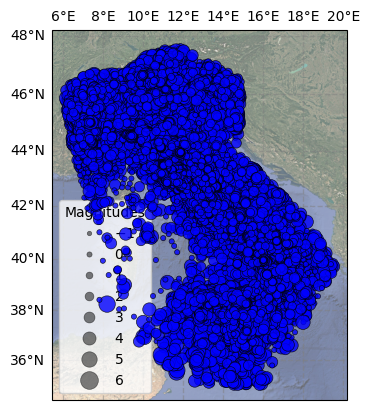

In [ ]:
cat.plot_in_space(include_map=True);

Legend added to the plot.


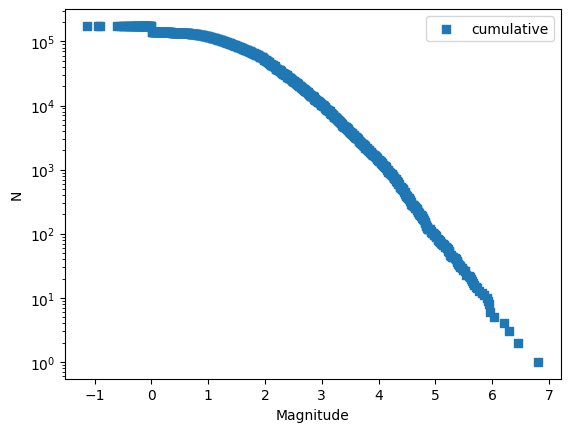

In [ ]:
cat.plot_cum_fmd();

## Estimatie mc and b values

In [ ]:
cat.delta_m = 0.1
cat.bin_magnitudes(inplace=True)

In [ ]:
print(cat.magnitude.head())

0    3.9
1    4.7
2    4.1
3    3.0
4    3.0
Name: magnitude, dtype: float64


In [ ]:
cat.estimate_mc_maxc(fmd_bin=0.1)
print(cat.mc)

0.2


In [ ]:
cat.estimate_mc_b_stability()
print(cat.mc)

/usr/local/lib/python3.12/dist-packages/seismostats/analysis/bvalue/base.py:119: UserWarning: No magnitudes in the lowest magnitude bin are present.Check if mc is chosen correctly.
  warnings.warn(


return_vals: {'best_b_value': np.float64(1.2367860665754902), 'mcs_tested': [-1.1, -1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3], 'b_values_tested': [np.float64(0.16790685868041283), np.float64(0.17465943301674644), np.float64(0.18197908090152223), np.float64(0.18993694893188395), np.float64(0.19862518995655062), np.float64(0.2081465401622785), np.float64(0.21862560648738794), np.float64(0.23021200901415856), np.float64(0.24309157254678213), np.float64(0.2574956953176918), np.float64(0.2736996493719224), np.float64(0.29206560795636644), np.float64(0.24720985767330805), np.float64(0.2618242150634443), np.float64(0.278046614949295), np.float64(0.29592283556129456), np.float64(0.31560309837206063), np.float64(0.3368741424242198), np.float64(0.3594503673585294

In [ ]:
mcs_test = bin_to_precision(
            np.arange(1.5, 5.0, 0.1), 0.1
)
best_mc, mc_info = cat.estimate_mc_ks(verbose=True, mcs_test=mcs_test, p_value_pass=0.05, delta_m=0.1, n=1000)
print(cat.mc)


Testing mc: 1.5.
..p-value: 0.0

Testing mc: 1.6.
..p-value: 0.0

Testing mc: 1.7.
..p-value: 0.0

Testing mc: 1.8.
..p-value: 0.0

Testing mc: 1.9.
..p-value: 0.0

Testing mc: 2.0.
..p-value: 0.0

Testing mc: 2.1.
..p-value: 0.0

Testing mc: 2.2.
..p-value: 0.0

Testing mc: 2.3.
..p-value: 0.0

Testing mc: 2.4.
..p-value: 0.0

Testing mc: 2.5.
..p-value: 0.0

Testing mc: 2.6.
..p-value: 0.0

Testing mc: 2.7.
..p-value: 0.0

Testing mc: 2.8.
..p-value: 0.0

Testing mc: 2.9.
..p-value: 0.0

Testing mc: 3.0.
..p-value: 0.0

Testing mc: 3.1.
..p-value: 0.003

Testing mc: 3.2.
..p-value: 0.002

Testing mc: 3.3.
..p-value: 0.003

Testing mc: 3.4.
..p-value: 0.0

Testing mc: 3.5.
..p-value: 0.0

Testing mc: 3.6.
..p-value: 0.0

Testing mc: 3.7.
..p-value: 0.0

Testing mc: 3.8.
..p-value: 0.0

Testing mc: 3.9.
..p-value: 0.0

Testing mc: 4.0.
..p-value: 0.003

Testing mc: 4.1.
..p-value: 0.046

Testing mc: 4.2.
..p-value: 0.102


Best mc to pass the test: 4.200 
with a b-value of: 1.179.
4.2

### 📊 Analysis of Completeness ($m_c$) Estimation Results

We evaluated three statistical approaches to determine the magnitude of completeness for the catalog:

#### **1. Maximum Curvature (MaxC) Method**
* **Result:** $m_c = 0.2$
* **Methodology:** Identifies the magnitude bin with the highest frequency of events (the peak of the non-cumulative frequency-magnitude distribution).

#### **2. $b$-value Stability Method**
* **Result:** $m_c = 4.3$
* **Methodology:** Scans for the lowest magnitude threshold where the estimated $b$-value stabilizes and ceases to fluctuate significantly with increasing cutoffs.

#### **3. Kolmogorov-Smirnov (KS) Test**
* **Result:** $m_c = 4.2$ (with $p\text{-value} = 0.102 > 0.05$)
* **Methodology:** Minimizes the KS distance between the observed data and a theoretical Gutenberg-Richter distribution to find the best goodness-of-fit.

---

### ⚠️ Parameter Selection for EEPAS Modeling

While the statistical tests (Stability and KS) suggest a conservative completeness threshold around $M \approx 4.2$, the EEPAS model requires a sufficient dynamic range between the completeness threshold ($m_0$) and the target forecasting magnitude ($m_T$).

* **Target Magnitude ($m_T$):** $5.0$
* **EEPAS Constraint:** The model requires that $m_0 \le m_T - 2.0$ to ensure a sufficient hierarchy of precursor magnitudes are included in the learning process.
* **Calculation:** $5.0 - 2.0 = 3.0$.

**Conclusion:** To satisfy the model's structural requirements while maximizing data usage, we select a threshold of **$m_0 = 3.0$**.


In [ ]:
cat.estimate_b(mc=3.0, delta_m=0.1)
cat.b_value

np.float64(0.8808434899293852)

In [ ]:
cat.estimate_b(mc=3.0, delta_m=0.1, method=UtsuBValueEstimator)
cat.b_value

np.float64(0.8778362810987849)

In [ ]:
cat.estimate_b(mc=3.0, delta_m=0.1, method=BPositiveBValueEstimator)
cat.b_value

np.float64(0.9698519369113587)

In [ ]:
cat.estimate_b(mc=3.0, delta_m=0.1, method=BMorePositiveBValueEstimator)
cat.b_value

np.float64(1.0133107669744423)

### 📊 Summary of b-value Estimation

We tested three different b-value estimation methods at mc = 3.0:

| Method | mc | b-value | B = b·ln(10) | Notes |
|--------|-----|---------|--------------|-------|
| **Utsu (MLE)** | 3.0 | 0.878 | 2.02 | Maximum Likelihood, unbiased for large samples |
| **B-positive** | 3.0 | 0.970 | 2.23 | Corrects positive bias |
| **B-more-positive** | 3.0 | 1.013 | 2.33 | Additional bias correction |


#### **Conclusion**
✅ The mc and b-value estimation provides a **range of reasonable values**  
✅ Proceed to **PPE Learning** (Step 1) using these parameters

---

## 🔗 Next Steps

After parameter estimation, the EEPAS workflow proceeds as:

1. **PPE Learning** (`ppe_learning.py`): Fit parameters a, d, s
2. **Aftershock Fitting** (`fit_aftershock_params.py`): Fit parameters ν, κ
3. **EEPAS Learning** (`eepas_learning_auto_boundary.py`): Fit all EEPAS parameters
4. **Forecast Generation**: Generate forecasts for testing period